## Single Layer Bidirectional GRU Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300)

In [120]:
# Standard Libraries
import numpy as np
import pandas as pd
import re

# NLP & Text Preprocessing
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec

# Machine Learning & Model Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, f1_score, roc_auc_score, accuracy_score, 
    classification_report, roc_curve
)
from sklearn.manifold import TSNE

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
data = pd.read_csv('yelp_reviews.csv')
data.shape

(20000, 9)

In [87]:
# Label Mapping
def map_label(star):
    if star >= 4:
        return "Positive"
    elif star == 3:
        return "Neutral"
    else:
        return "Negative"

data['label'] = data['stars'].apply(map_label)

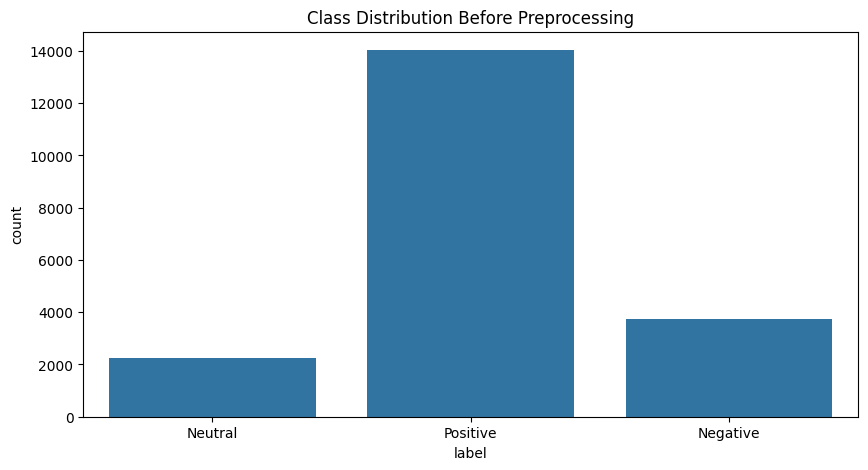

In [88]:
# Visualization before preprocessing
plt.figure(figsize=(10,5))
sns.countplot(x=data['label'])
plt.title('Class Distribution Before Preprocessing')
plt.show()

### Data Cleaning

In [89]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Emoji, slang, and abbreviation handling (example)
emoji_dict = {":)": "happy", ":(": "sad"}
slang_dict = {"brb": "be right back", "lol": "laugh out loud"}
abbr_dict = {"asap": "as soon as possible"}

def handle_emojis_slangs_abbr(text):
    for emoji, replacement in emoji_dict.items():
        text = text.replace(emoji, replacement)
    for slang, replacement in slang_dict.items():
        text = text.replace(slang, replacement)
    for abbr, replacement in abbr_dict.items():
        text = text.replace(abbr, replacement)
    return text

# Update the preprocess_text function to include all steps
def preprocess_text(text):
    # First, handle emojis, slangs, and abbreviations
    text = handle_emojis_slangs_abbr(text)
    
    # Regex to remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Regex to remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Split the text into words
    words = text.split()
    
    # Remove stop words and lemmatize the words
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Join the words back into a single string
    text = ' '.join(words)
    
    return text

# Apply the preprocessing function to the 'text' column
data['cleaned_text'] = data['text'].apply(preprocess_text)


In [90]:
# Make sure to import TextBlob at the top
from textblob import TextBlob

# Add features (e.g., sentence length, sentiment score)
def add_features(data):
    data['sentence_length'] = data['cleaned_text'].apply(lambda x: len(x.split()))  # Sentence length
    data['sentiment_score'] = data['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)  # Sentiment score
    return data

# Now call the function and inspect the data
data = add_features(data)
data.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,label,cleaned_text,sentence_length,sentiment_score
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Neutral,decide eat aware going take hour beginning end...,43,0.198485
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Positive,ive taken lot spin class year nothing compare ...,82,0.395455
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Neutral,family diner buffet eclectic assortment large ...,39,0.139935
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Positive,wow yummy different delicious favorite lamb cu...,23,0.315152
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Positive,cute interior owner gave u tour upcoming patio...,63,0.416234


### Data Splitting

In [91]:
# Split data into train and test sets
X = data['text']
y = data['label']  # Replace 'label' with your target column

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(14000,) (6000,)


### Text Preprocessing 

In [92]:
# Tokenize text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)  # Fit tokenizer only on training data
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding token

# Convert texts to sequences of word indices
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences
max_sequence_length = max(len(seq) for seq in X_train_seq)  # Use max sequence length from the training data
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post')

# Convert labels to numpy array
y_train = np.array(y_train)
y_test = np.array(y_test)

# Label Encoding the target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Encode training labels
y_test_encoded = label_encoder.transform(y_test)  # Encode test labels

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train_encoded)
y_test_one_hot = to_categorical(y_test_encoded)


In [93]:
# Train Word2Vec on the training data only
def train_word2vec(texts, vector_size=128, window=5, min_count=1, sg=1):
    sentences = [text.split() for text in texts]  # Split text into words for Word2Vec
    model = Word2Vec(sentences, vector_size=vector_size, window=window, min_count=min_count, sg=sg)
    return model

# Train Word2Vec
word2vec_model = train_word2vec(X_train, vector_size=128, sg=1)  # sg=1 for Skipgram, sg=0 for CBOW

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, 128))  # Initialize the matrix with zeros
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]  # Assign word embeddings

### Model Building - iteration 1

In [98]:
# Build the Bidirectional GRU Model

def build_bidirectional_gru(vocab_size, embedding_matrix, max_sequence_length, num_classes):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, weights=[embedding_matrix], 
                        input_length=max_sequence_length, trainable=False))
    model.add(Bidirectional(GRU(64, return_sequences=False)))
    model.add(Dropout(0.2))  # Dropout layer added
    model.add(Dense(3, activation='softmax'))  # Use softmax for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

num_classes = 3  # The number of unique classes in the target
model = build_bidirectional_gru(vocab_size, embedding_matrix, max_sequence_length, num_classes)

# Show the model summary
model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_39 (Embedding)        │ ?                      │     3,825,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_57                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,825,152 (14.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,825,152 (14.59 MB)

In [99]:
# Define the EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the Model with EarlyStopping
history = model.fit(
    X_train_pad, y_train_one_hot,
    epochs=15,
    batch_size=32,
    validation_split=0.3,
    callbacks=[early_stopping]  # Add early stopping callback here
)

Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 75s 243ms/step - accuracy: 0.6875 - loss: 0.7996 - val_accuracy: 0.7843 - val_loss: 0.5860
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 82s 268ms/step - accuracy: 0.7884 - loss: 0.5575 - val_accuracy: 0.8005 - val_loss: 0.5240
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 82s 267ms/step - accuracy: 0.8148 - loss: 0.4949 - val_accuracy: 0.8195 - val_loss: 0.4809
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 270ms/step - accuracy: 0.8307 - loss: 0.4497 - val_accuracy: 0.8195 - val_loss: 0.4566
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 282ms/step - accuracy: 0.8339 - loss: 0.4252 - val_accuracy: 0.8245 - val_loss: 0.4459
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 86s 280ms/step - accuracy: 0.8484 - loss: 0.3944 - val_accuracy: 0.8210 - val_loss: 0.4350
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 82s 267ms/step - accuracy: 0.8495 - loss: 0.3798 - val_accuracy: 0.8214 - val_loss: 0.4460
Epoch 8/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 270ms/step - accuracy: 0.8579 - loss: 0

### Evaluation - iteration 1

In [100]:
# Evaluate on Training Data
y_train_pred = model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_pred, axis=1)  # Convert probabilities to class indices
y_train_true = np.argmax(y_train_one_hot, axis=1)  # Convert one-hot encoding back to labels

print("Training Confusion Matrix:")
print(confusion_matrix(y_train_true, y_train_pred))
print("Training Classification Report:\n", classification_report(y_train_true, y_train_pred))
print("Training AUC:", roc_auc_score(y_train_one_hot, model.predict(X_train_pad), multi_class='ovr'))
print("Training Accuracy:", accuracy_score(y_train_true, y_train_pred))

438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step
Training Confusion Matrix:
[[2111  223  288]
 [ 379  513  690]
 [ 240  319 9237]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.81      0.79      2622
           1       0.49      0.32      0.39      1582
           2       0.90      0.94      0.92      9796

    accuracy                           0.85     14000
   macro avg       0.72      0.69      0.70     14000
weighted avg       0.83      0.85      0.84     14000

438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step
Training AUC: 0.9249726385985443
Training Accuracy: 0.8472142857142857


In [101]:
# Evaluate on Testing Data
y_test_pred = model.predict(X_test_pad)
y_test_pred = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test_one_hot, axis=1)

print("Testing Confusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))
print("Testing Classification Report:\n", classification_report(y_test_true, y_test_pred))
print("Testing AUC:", roc_auc_score(y_test_one_hot, model.predict(X_test_pad), multi_class='ovr'))
print("Testing Accuracy:", accuracy_score(y_test_true, y_test_pred))

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step
Testing Confusion Matrix:
[[ 869   99  138]
 [ 155  199  305]
 [ 110  159 3966]]
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.79      0.78      1106
           1       0.44      0.30      0.36       659
           2       0.90      0.94      0.92      4235

    accuracy                           0.84      6000
   macro avg       0.70      0.67      0.68      6000
weighted avg       0.82      0.84      0.83      6000

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step
Testing AUC: 0.9111291888075145
Testing Accuracy: 0.839


188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step


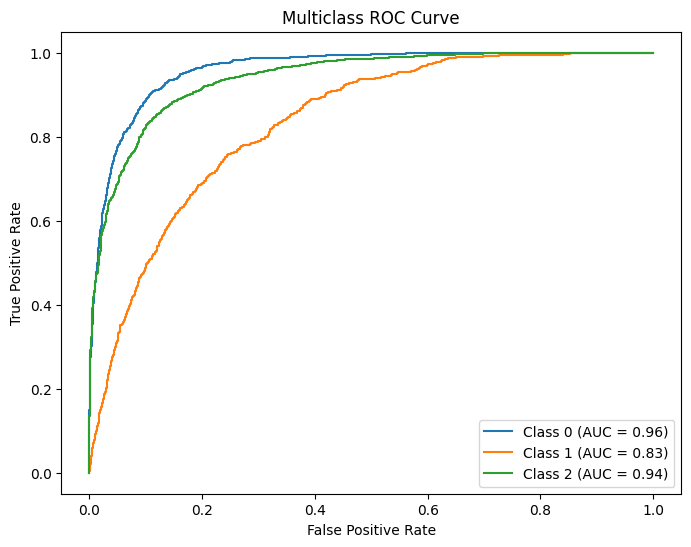

In [102]:
y_test_bin = label_binarize(y_test_true, classes=np.arange(num_classes))
y_pred_probs = model.predict(X_test_pad)

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_score(y_test_bin[:, i], y_pred_probs[:, i]):.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

### iteration 2

In [48]:
# Compute Class Weights
y_train_labels = np.argmax(y_train_one_hot, axis=1)  
class_weight_dict = dict(enumerate(compute_class_weight("balanced", classes=np.unique(y_train_labels), y=y_train_labels)))  
print("Computed Class Weights:", class_weight_dict)

# Modify the model to reduce overfitting
def build_bidirectional_gru_v2(vocab_size, embedding_matrix, max_sequence_length, num_classes):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, weights=[embedding_matrix], trainable=False))  # Removed input_length
    model.add(Bidirectional(GRU(64, return_sequences=False)))  # Use return_sequences for more complex architectures
    model.add(Dropout(0.3))  # Add dropout to reduce overfitting
    model.add(Dense(3, activation='softmax'))  # Output layer with softmax for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Categorical crossentropy for multiclass
    return model

# Build the model again after modification
model_2 = build_bidirectional_gru_v2(vocab_size, embedding_matrix, max_sequence_length, num_classes)
model_2.summary()

Computed Class Weights: {0: 1.779811848461734, 1: 2.949852507374631, 2: 0.47638491901456376}


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │     3,825,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_22                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,825,152 (14.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,825,152 (14.59 MB)

In [49]:
# Define Early Stopping
early_stopping_2 = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train Model with Class Weights
history_2 = model_2.fit(
    X_train_pad, y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.3,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_2]
)  

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 75s 242ms/step - accuracy: 0.4573 - loss: 1.0447 - val_accuracy: 0.6295 - val_loss: 0.9098
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 270ms/step - accuracy: 0.6818 - loss: 0.8310 - val_accuracy: 0.5490 - val_loss: 0.9097
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 84s 272ms/step - accuracy: 0.7038 - loss: 0.7344 - val_accuracy: 0.6205 - val_loss: 0.7729
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 270ms/step - accuracy: 0.7360 - loss: 0.6785 - val_accuracy: 0.7555 - val_loss: 0.5818
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 269ms/step - accuracy: 0.7702 - loss: 0.6144 - val_accuracy: 0.7079 - val_loss: 0.6581
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 84s 275ms/step - accuracy: 0.7702 - loss: 0.5826 - val_accuracy: 0.7729 - val_loss: 0.5403
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 86s 280ms/step - accuracy: 0.7729 - loss: 0.5811 - val_accuracy: 0.6855 - val_loss: 0.6843
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 83s 272ms/step - accuracy: 0.7982 - loss: 0

### Evaluation - iteration 2

In [55]:
# Evaluate on Training Data
y_train_pred = model_2.predict(X_train_pad)
y_train_pred = np.argmax(y_train_pred, axis=1)  # Convert probabilities to class indices
y_train_true = np.argmax(y_train_one_hot, axis=1)  # Convert one-hot encoding back to labels

print("Training Confusion Matrix:")
print(confusion_matrix(y_train_true, y_train_pred))
print("Training Classification Report:\n", classification_report(y_train_true, y_train_pred))
print("Training AUC:", roc_auc_score(y_train_one_hot, model_2.predict(X_train_pad), multi_class='ovr'))
print("Training Accuracy:", accuracy_score(y_train_true, y_train_pred))

438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step
Training Confusion Matrix:
[[2067  425  130]
 [ 180  960  442]
 [ 288  771 8737]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80      2622
           1       0.45      0.61      0.51      1582
           2       0.94      0.89      0.91      9796

    accuracy                           0.84     14000
   macro avg       0.73      0.76      0.74     14000
weighted avg       0.86      0.84      0.85     14000

438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step
Training AUC: 0.9344876974050541
Training Accuracy: 0.8402857142857143


In [56]:
# Evaluate on Testing Data
y_test_pred = model_2.predict(X_test_pad)
y_test_pred = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test_one_hot, axis=1)

print("Testing Confusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))
print("Testing Classification Report:\n", classification_report(y_test_true, y_test_pred))
print("Testing AUC:", roc_auc_score(y_test_one_hot, model_2.predict(X_test_pad), multi_class='ovr'))
print("Testing Accuracy:", accuracy_score(y_test_true, y_test_pred))

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step
Testing Confusion Matrix:
[[ 801  234   71]
 [ 119  329  211]
 [ 133  385 3717]]
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.72      0.74      1106
           1       0.35      0.50      0.41       659
           2       0.93      0.88      0.90      4235

    accuracy                           0.81      6000
   macro avg       0.68      0.70      0.68      6000
weighted avg       0.83      0.81      0.82      6000

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step
Testing AUC: 0.9039511476924093
Testing Accuracy: 0.8078333333333333


188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step


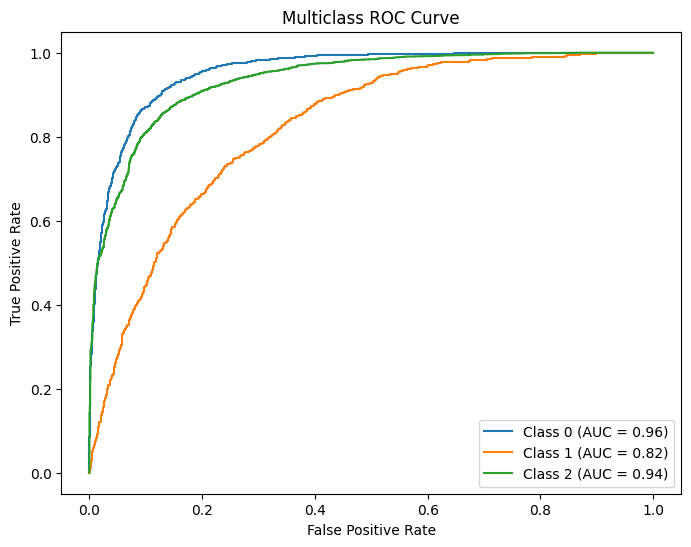

In [57]:
# Binarize the labels for multiclass (ensure correct shape)
y_test_bin = label_binarize(y_test_one_hot, classes=np.arange(num_classes))

# Get predicted probabilities (ensure that this is output from softmax layer)
y_pred_probs = model_2.predict(X_test_pad)

# Plot AUC for multiclass
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()


### iteration 3

In [71]:
# Compute Class Weights
y_train_labels = np.argmax(y_train_one_hot, axis=1)  
class_weight_dict = dict(enumerate(compute_class_weight("balanced", classes=np.unique(y_train_labels), y=y_train_labels)))  
print("Computed Class Weights:", class_weight_dict)

# Modify the model to reduce overfitting
def build_bidirectional_gru_v3(vocab_size, embedding_matrix, max_sequence_length, num_classes):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, weights=[embedding_matrix], trainable=False))  # Removed input_length
    model.add(Bidirectional(GRU(128, return_sequences=False)))  # Use return_sequences for more complex architectures
    model.add(Dropout(0.5))  # Add dropout to reduce overfitting
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Added dense layer with L2 regularization
    model.add(Dropout(0.5))  # Dropout after Dense layer
    model.add(Dense(3, activation='softmax'))  # Output layer with softmax for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Categorical crossentropy for multiclass
    return model

# Build the model again after modification
model_3 = build_bidirectional_gru_v3(vocab_size, embedding_matrix, max_sequence_length, num_classes)
model_3.summary()

Computed Class Weights: {0: 1.779811848461734, 1: 2.949852507374631, 2: 0.47638491901456376}


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │     3,825,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_28                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,825,152 (14.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,825,152 (14.59 MB)

In [72]:
# Define EarlyStopping
early_stopping_3 = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train Model with Class Weights
history_3 = model_3.fit(
    X_train_pad, y_train_one_hot,
    epochs=15,
    batch_size=32,
    validation_split=0.3,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_3]
)


Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 153s 496ms/step - accuracy: 0.4336 - loss: 1.8245 - val_accuracy: 0.7543 - val_loss: 0.7491
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 164s 535ms/step - accuracy: 0.6516 - loss: 0.9637 - val_accuracy: 0.7083 - val_loss: 0.7472
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 163s 531ms/step - accuracy: 0.7194 - loss: 0.8152 - val_accuracy: 0.7250 - val_loss: 0.6815
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 165s 539ms/step - accuracy: 0.7250 - loss: 0.7405 - val_accuracy: 0.7502 - val_loss: 0.6531
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 166s 539ms/step - accuracy: 0.7363 - loss: 0.7313 - val_accuracy: 0.7886 - val_loss: 0.5716
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 167s 545ms/step - accuracy: 0.7441 - loss: 0.6854 - val_accuracy: 0.8169 - val_loss: 0.5211
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 166s 541ms/step - accuracy: 0.7614 - loss: 0.6579 - val_accuracy: 0.7729 - val_loss: 0.5824
Epoch 8/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 169s 552ms/step - accuracy: 0.7836 -

### Evaluation - iteration 3

In [73]:
# Evaluate on Training Data
y_train_pred = model_3.predict(X_train_pad)
y_train_pred = np.argmax(y_train_pred, axis=1)  # Convert probabilities to class indices
y_train_true = np.argmax(y_train_one_hot, axis=1)  # Convert one-hot encoding back to labels

print("Training Confusion Matrix:")
print(confusion_matrix(y_train_true, y_train_pred))
print("Training Classification Report:\n", classification_report(y_train_true, y_train_pred))
print("Training AUC:", roc_auc_score(y_train_one_hot, model_3.predict(X_train_pad), multi_class='ovr'))
print("Training Accuracy:", accuracy_score(y_train_true, y_train_pred))

438/438 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step
Training Confusion Matrix:
[[1754  491  377]
 [ 156  713  713]
 [ 132  439 9225]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75      2622
           1       0.43      0.45      0.44      1582
           2       0.89      0.94      0.92      9796

    accuracy                           0.84     14000
   macro avg       0.73      0.69      0.70     14000
weighted avg       0.84      0.84      0.83     14000

438/438 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step
Training AUC: 0.9174496160081435
Training Accuracy: 0.8351428571428572


In [74]:
# Evaluate on Testing Data
y_test_pred = model_3.predict(X_test_pad)
y_test_pred = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test_one_hot, axis=1)

print("Testing Confusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))
print("Testing Classification Report:\n", classification_report(y_test_true, y_test_pred))
print("Testing AUC:", roc_auc_score(y_test_one_hot, model_3.predict(X_test_pad), multi_class='ovr'))
print("Testing Accuracy:", accuracy_score(y_test_true, y_test_pred))

188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step
Testing Confusion Matrix:
[[ 701  237  168]
 [  72  274  313]
 [  54  227 3954]]
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.63      0.73      1106
           1       0.37      0.42      0.39       659
           2       0.89      0.93      0.91      4235

    accuracy                           0.82      6000
   macro avg       0.70      0.66      0.68      6000
weighted avg       0.83      0.82      0.82      6000

188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step
Testing AUC: 0.9009295274757992
Testing Accuracy: 0.8215


188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step


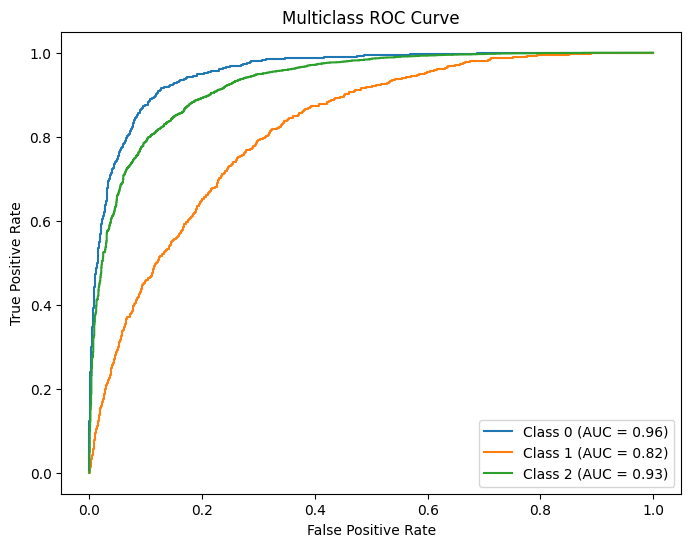

In [75]:
# Binarize the labels for multiclass (ensure correct shape)
y_test_bin = label_binarize(y_test_one_hot, classes=np.arange(num_classes))

# Get predicted probabilities (ensure that this is output from softmax layer)
y_pred_probs = model_3.predict(X_test_pad)

# Plot AUC for multiclass
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()


### Class Seperability

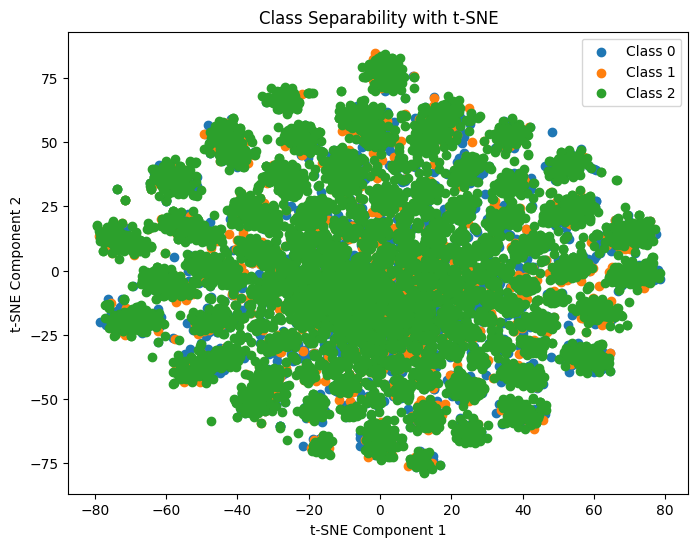

In [103]:
# Reduce to 2 dimensions using t-SNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_train_pad)

# Plotting
plt.figure(figsize=(8, 6))
for label in np.unique(np.argmax(y_train_one_hot, axis=1)):
    plt.scatter(X_tsne[np.argmax(y_train_one_hot, axis=1) == label, 0], 
                X_tsne[np.argmax(y_train_one_hot, axis=1) == label, 1], 
                label=f"Class {label}")
plt.title("Class Separability with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


### Cross-validation

In [109]:
# Ensure data is in NumPy format
X_train_pad = np.array(X_train_pad)
y_train_one_hot = np.array(y_train_one_hot)

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=3)
cross_val_scores = []

for train_idx, val_idx in skf.split(X_train_pad, np.argmax(y_train_one_hot, axis=1)):  
    X_train, X_val = X_train_pad[train_idx], X_train_pad[val_idx]
    y_train, y_val = y_train_one_hot[train_idx], y_train_one_hot[val_idx]
    
    # Build & train model
    model = build_bidirectional_gru(vocab_size, embedding_matrix, max_sequence_length, num_classes)
    model.fit(X_train, y_train, epochs=3, batch_size=32, verbose=1)
    
    # Predict & evaluate
    y_pred = np.argmax(model.predict(X_val), axis=1)
    accuracy = np.mean(y_pred == np.argmax(y_val, axis=1))
    
    cross_val_scores.append(accuracy)

# Print results
print("Cross-validation accuracy scores:", cross_val_scores)
print("Mean cross-validation accuracy:", np.mean(cross_val_scores))

Epoch 1/3


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


292/292 ━━━━━━━━━━━━━━━━━━━━ 65s 218ms/step - accuracy: 0.6909 - loss: 0.8113
Epoch 2/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 71s 244ms/step - accuracy: 0.7897 - loss: 0.5701
Epoch 3/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 72s 245ms/step - accuracy: 0.8036 - loss: 0.5108
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
Epoch 1/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 65s 219ms/step - accuracy: 0.7134 - loss: 0.7595
Epoch 2/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 72s 247ms/step - accuracy: 0.7799 - loss: 0.5731
Epoch 3/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 72s 245ms/step - accuracy: 0.7999 - loss: 0.5262
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
Epoch 1/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 65s 219ms/step - accuracy: 0.6941 - loss: 0.7920
Epoch 2/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 72s 246ms/step - accuracy: 0.7841 - loss: 0.5712
Epoch 3/3
292/292 ━━━━━━━━━━━━━━━━━━━━ 72s 246ms/step - accuracy: 0.8115 - loss: 0.4981
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
Cross-validation accuracy scores: [0.8264409685022498, 0.8097278765802443, 0.793399057008144

### Model Intepretability

In [113]:
# Check the shape of your data
print(X_train_pad.shape)

# Test model prediction on a small batch
print(model.predict(X_train_pad[:10]))

# Feature Importance using SHAP
try:
    explainer = shap.DeepExplainer(model, X_train_pad[:100])  # Use a subset for faster computation
    shap_values = explainer.shap_values(X_train_pad[:100])

    # Ensure shap_values are not None
    if shap_values is None:
        print("SHAP values could not be computed. Please check the model and data compatibility.")
    else:
        shap.summary_plot(shap_values, X_train_pad[:100], feature_names=tokenizer.word_index)
except Exception as e:
    print("Error during SHAP computation:", str(e))

(14000, 951)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.08151492 0.16845053 0.7500345 ]
 [0.09037402 0.2550518  0.65457416]
 [0.03568013 0.10752757 0.85679233]
 [0.02238908 0.10325076 0.87436014]
 [0.06167981 0.1553122  0.78300804]
 [0.22581379 0.14427193 0.6299142 ]
 [0.8239001  0.15152527 0.02457466]
 [0.20984985 0.1869926  0.6031576 ]
 [0.8933529  0.08013176 0.02651534]
 [0.0429221  0.05367609 0.9034018 ]]
Error during SHAP computation: 'NoneType' object has no attribute 'numpy'
